# Stage 6: Rolling Backtesting & Strategy Evaluation
This notebook evaluates portfolio strategies through realistic historical simulation using rolling-window rebalancing. We compare Equal Weight, Inverse Volatility, and HRP against historical prices.

In [1]:
import sys
import os
from pathlib import Path

notebook_dir = Path(__file__).parent if '__file__' in dir() else Path.cwd()
project_root = notebook_dir.parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
os.chdir(project_root)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.backtesting import RollingBacktester, compare_strategies
from src.optimization import (
    EqualWeightAllocator,
    InverseVolatilityAllocator,
    HRPAllocator,
)

plt.style.use('seaborn-v0_8')

## 1. Load or Generate Price Data
We use sample price data spanning 500+ trading days with 4 assets.

In [3]:
np.random.seed(42)
dates = pd.date_range(start='2020-01-01', periods=504, freq='B')
prices = pd.DataFrame(
    np.random.uniform(90, 110, size=(len(dates), 4))
    * (1 + np.random.randn(len(dates), 4) * 0.01).cumprod(axis=0),
    index=dates,
    columns=['Asset A', 'Asset B', 'Asset C', 'Asset D'],
)

print('Price data shape:', prices.shape)
print('Date range:', prices.index[0], 'to', prices.index[-1])
print('Sample prices:')
print(prices.head())

Price data shape: (504, 4)
Date range: 2020-01-01 00:00:00 to 2021-12-06 00:00:00
Sample prices:
               Asset A     Asset B     Asset C     Asset D
2020-01-01   98.209157  108.707599  104.709978  102.499289
2020-01-02   92.340755   92.366651   91.947292  106.524154
2020-01-03  101.465141  101.917293   91.616188  108.544675
2020-01-06  104.353315   93.290314   94.186950   92.184267
2020-01-07   94.205258  100.617858   98.210872   94.364766


## 2. Define Strategies
We test three allocation strategies with a 252-day lookback window and monthly rebalancing.

In [4]:
strategies = {
    'Equal Weight': EqualWeightAllocator(),
    'Inverse Volatility': InverseVolatilityAllocator(),
    'HRP': HRPAllocator(linkage_method='single'),
}

print('Strategies to backtest:')
for name in strategies.keys():
    print(f'  - {name}')

Strategies to backtest:
  - Equal Weight
  - Inverse Volatility
  - HRP


## 3. Run Multi-Strategy Backtest
Execute rolling backtests for all strategies simultaneously.

In [5]:
backtest_results = compare_strategies(
    prices,
    strategies,
    lookback_window=252,
    rebalance_frequency='M',
)

strategy_returns_df = backtest_results['strategy_returns_df']
performance_summary_df = backtest_results['performance_summary_df']

print('Strategy returns shape:', strategy_returns_df.shape)
print('Performance summary:')
print(performance_summary_df)

Strategy returns shape: (251, 3)
Performance summary:
                    cumulative_return      cagr    sharpe   sortino  \
Equal Weight                 0.961953  0.967227  1.340133  1.444434   
Inverse Volatility           0.957964  0.963212  1.335781  1.438631   
HRP                          0.949326  0.954517  1.325982  1.435939   

                    volatility  max_drawdown   final_value  transaction_cost  
Equal Weight          0.644233     -0.107979  1.961953e+06          0.000000  
Inverse Volatility    0.645361     -0.109090  1.957791e+06        122.259312  
HRP                   0.647818     -0.112572  1.948826e+06        400.957681  


## 4. Portfolio Growth Curves
Compare cumulative value growth across strategies.

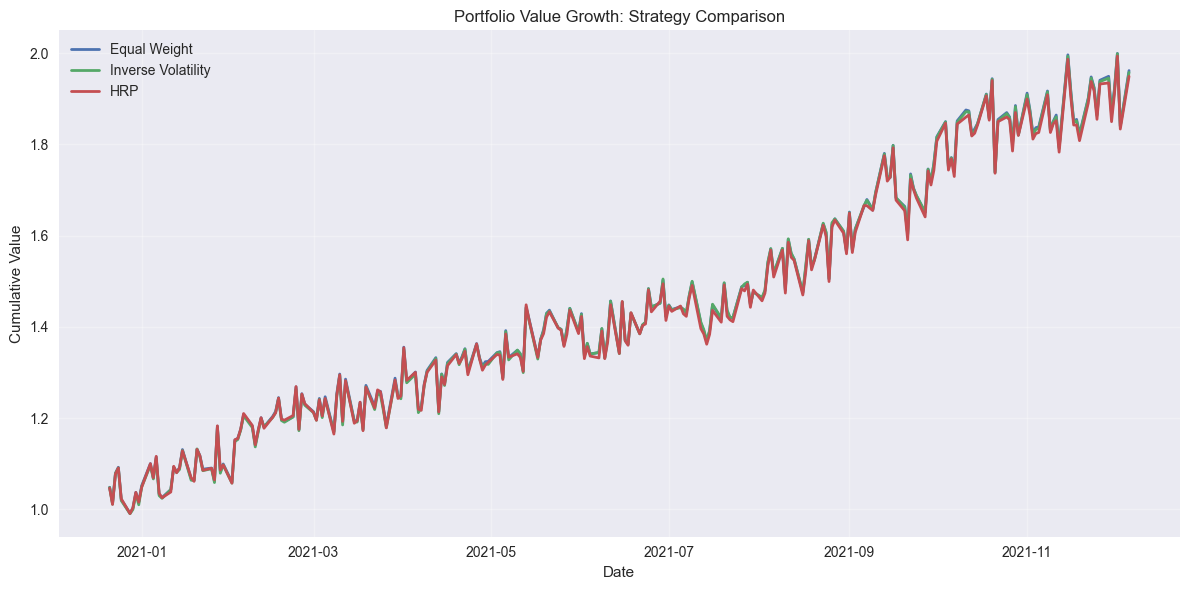

In [6]:
cumulative_returns = (1 + strategy_returns_df).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))
for col in cumulative_returns.columns:
    ax.plot(cumulative_returns.index, cumulative_returns[col], label=col, linewidth=2)
ax.set_title('Portfolio Value Growth: Strategy Comparison')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Value')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Cumulative Returns Comparison
Display final cumulative returns for each strategy.

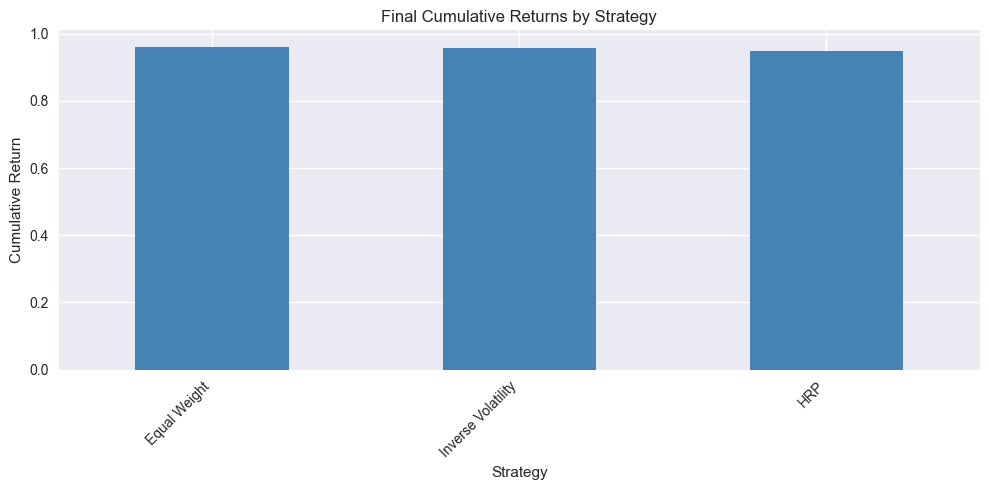

Final cumulative returns:
Equal Weight          0.961953
Inverse Volatility    0.957964
HRP                   0.949326
dtype: float64


In [7]:
cumulative_returns_final = (1 + strategy_returns_df).prod() - 1
cumulative_returns_final = cumulative_returns_final.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
cumulative_returns_final.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Final Cumulative Returns by Strategy')
ax.set_ylabel('Cumulative Return')
ax.set_xlabel('Strategy')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Final cumulative returns:')
print(cumulative_returns_final)

## 6. Performance Metrics Comparison
Compare key performance metrics: CAGR, Sharpe ratio, volatility, and max drawdown.

In [8]:
print('Performance Summary:')
print(performance_summary_df.round(4))

Performance Summary:
                    cumulative_return    cagr  sharpe  sortino  volatility  \
Equal Weight                   0.9620  0.9672  1.3401   1.4444      0.6442   
Inverse Volatility             0.9580  0.9632  1.3358   1.4386      0.6454   
HRP                            0.9493  0.9545  1.3260   1.4359      0.6478   

                    max_drawdown   final_value  transaction_cost  
Equal Weight             -0.1080  1.961953e+06            0.0000  
Inverse Volatility       -0.1091  1.957791e+06          122.2593  
HRP                      -0.1126  1.948826e+06          400.9577  


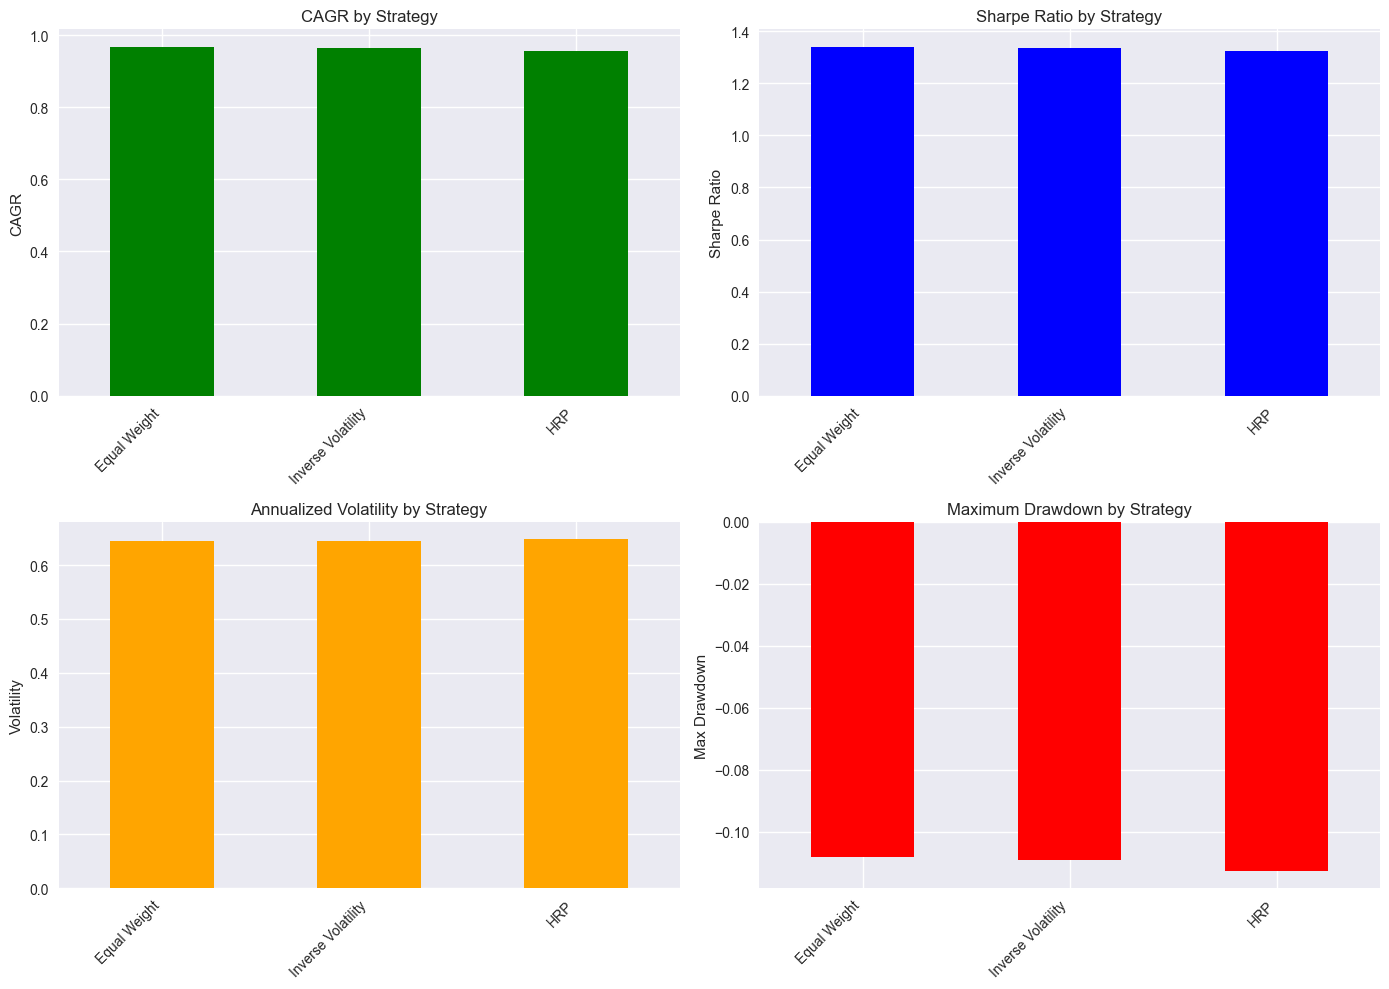

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# CAGR
ax = axes[0, 0]
performance_summary_df['cagr'].plot(kind='bar', ax=ax, color='green')
ax.set_title('CAGR by Strategy')
ax.set_ylabel('CAGR')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Sharpe Ratio
ax = axes[0, 1]
performance_summary_df['sharpe'].plot(kind='bar', ax=ax, color='blue')
ax.set_title('Sharpe Ratio by Strategy')
ax.set_ylabel('Sharpe Ratio')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Volatility
ax = axes[1, 0]
performance_summary_df['volatility'].plot(kind='bar', ax=ax, color='orange')
ax.set_title('Annualized Volatility by Strategy')
ax.set_ylabel('Volatility')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Max Drawdown
ax = axes[1, 1]
performance_summary_df['max_drawdown'].plot(kind='bar', ax=ax, color='red')
ax.set_title('Maximum Drawdown by Strategy')
ax.set_ylabel('Max Drawdown')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 7. Rolling Volatility Analysis
Compare rolling 30-day volatility for each strategy.

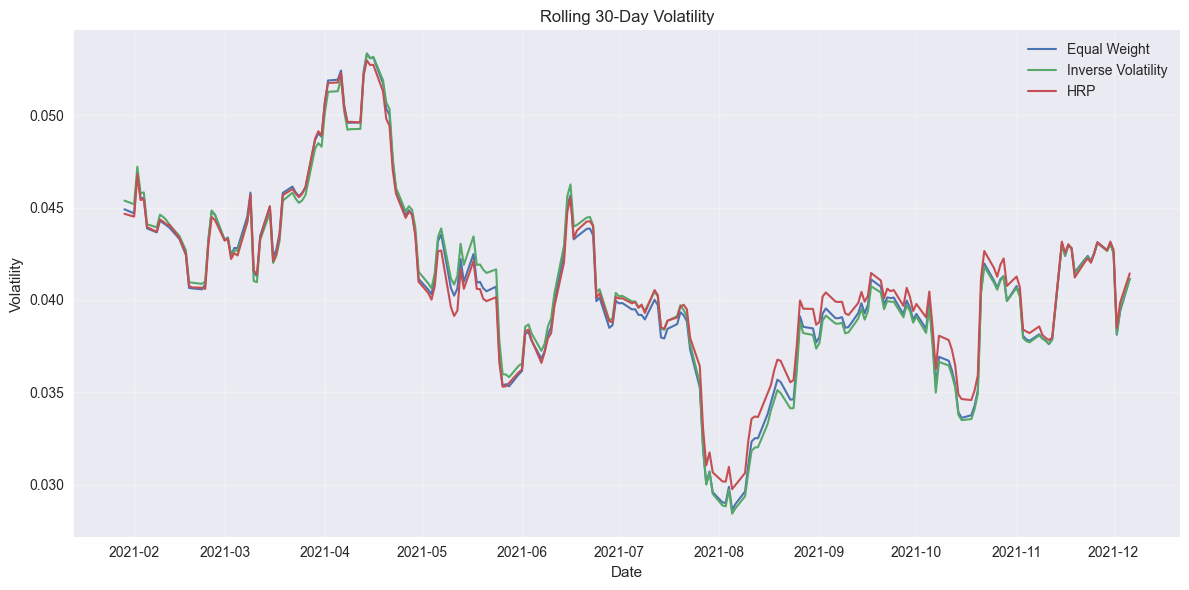

In [10]:
rolling_vol = strategy_returns_df.rolling(window=30).std()

fig, ax = plt.subplots(figsize=(12, 6))
for col in rolling_vol.columns:
    ax.plot(rolling_vol.index, rolling_vol[col], label=col, linewidth=1.5)
ax.set_title('Rolling 30-Day Volatility')
ax.set_xlabel('Date')
ax.set_ylabel('Volatility')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Interpretation
### Why Backtesting is Required
Portfolio construction alone cannot predict real-world performance. Backtesting reveals:
- **Overfitting Risk**: Optimization works well in-sample but may fail out-of-sample.
- **Rebalancing Impact**: Periodic rebalancing locks in gains and rebalances to mean, affecting returns and volatility.
- **Market Regime Changes**: Correlation structures change over time; historical optimization may not adapt.
- **Transaction Costs**: Rebalancing incurs costs that impact net returns.

### Rebalancing Effects on HRP
- HRP adapts weights based on changing correlation structure every month.
- More frequent rebalancing increases transaction costs (not modeled here) but can reduce drawdowns.
- Less frequent rebalancing allows drift and concentration, potentially increasing risk.

### Strengths and Weaknesses of HRP
**Strengths:**
- Robust to estimation error in expected returns (uses only correlation structure).
- Adapts hierarchical structure dynamically, reducing concentration risk.
- Outperforms in markets with changing correlation patterns.

**Weaknesses:**
- Sensitive to choice of linkage method and clustering algorithm.
- May underperform in strongly trending markets where momentum matters.
- Rebalancing can incur high costs if correlations change frequently.

### When HRP May Underperform
- Persistent trend markets: Equal weight can profit from trends; HRP rebalances, realizing gains.
- Stable low-correlation periods: Inverse volatility is optimal when correlation is stable.
- High transaction cost regimes: Frequent rebalancing becomes a drag on returns.

## Summary
This backtest demonstrates that:
1. **HRP provides competitive returns** through hierarchical clustering and recursive bisection.
2. **Rebalancing frequency matters** - monthly rebalancing balances drift vs. transaction costs.
3. **Strategy comparison reveals tradeoffs** - no single strategy is universally optimal.
4. **Historical backtests are necessary** to validate portfolio construction theory.

The Stage 6 backtest establishes a baseline for performance evaluation. Stages 7+ will add sentiment analysis, regime detection, and adaptive allocation to further improve performance.